# 🎬🌳 Regresión logística binaria (1-0)

In [1]:
# ─────────────────────────────────────────────────────────────
# CELDA 0 — Conexión a ETL-Proyecto y configuración
# ─────────────────────────────────────────────────────────────

import sys
import os

# Detectar raíz del proyecto
if "notebooks" in os.getcwd():
    ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
else:
    ROOT_DIR = os.getcwd()

ETL_DIR = os.path.join(ROOT_DIR, "Etl-Proyecto")

if ETL_DIR not in sys.path:
    sys.path.append(ETL_DIR)

# Carpeta para gráficas
GRAFICAS_DIR = os.path.join(
    ROOT_DIR,
    "data",
    "graficas",
    "regresion_logistica_binaria"
)

os.makedirs(GRAFICAS_DIR, exist_ok=True)

print("=" * 60)
print("CONFIGURACIÓN DEL PROYECTO")
print("=" * 60)
print(f"📁 ROOT_DIR      : {ROOT_DIR}")
print(f"📁 ETL_DIR       : {ETL_DIR}")
print(f"📁 GRAFICAS_DIR  : {GRAFICAS_DIR}")
print("✅ Configuración completada")

CONFIGURACIÓN DEL PROYECTO
📁 ROOT_DIR      : /home/desarrollo/Grupo6_Obregon_Heredia_MD1
📁 ETL_DIR       : /home/desarrollo/Grupo6_Obregon_Heredia_MD1/Etl-Proyecto
📁 GRAFICAS_DIR  : /home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/regresion_logistica_binaria
✅ Configuración completada


In [2]:
# ─────────────────────────────────────────────────────────────
# CELDA 1 — Importación de librerías
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    classification_report
)

from scripts.database import engine

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11
})

print("=" * 60)
print("LIBRERÍAS CARGADAS")
print("=" * 60)
print(f"✅ pandas   : {pd.__version__}")
print(f"✅ numpy    : {np.__version__}")
print(f"✅ seaborn  : {sns.__version__}")

LIBRERÍAS CARGADAS
✅ pandas   : 2.3.3
✅ numpy    : 1.26.4
✅ seaborn  : 0.13.2


In [3]:
# ─────────────────────────────────────────────────────────────
# CELDA 2 — Extracción de datos desde PostgreSQL
# ─────────────────────────────────────────────────────────────

QUERY = """
SELECT
    anio,
    imdb_rating
FROM registro_peliculas
WHERE imdb_rating IS NOT NULL
AND anio IS NOT NULL
"""

df = pd.read_sql(QUERY, engine)

print("=" * 60)
print("DATOS EXTRAÍDOS")
print("=" * 60)
print(f"✅ Registros cargados : {len(df):,}")
print(f"✅ Columnas           : {list(df.columns)}")

df.head()

DATOS EXTRAÍDOS
✅ Registros cargados : 528
✅ Columnas           : ['anio', 'imdb_rating']


,anio,imdb_rating
0,2010,8.8
1,2014,8.7
2,2008,9.1
3,2019,8.5
4,2009,7.9


In [4]:
# ─────────────────────────────────────────────────────────────
# CELDA 3 — Creación de variable objetivo binaria
# ─────────────────────────────────────────────────────────────

# 1 = Película exitosa
# 0 = Película no exitosa

df["exito"] = (df["imdb_rating"] >= 7).astype(int)

print("=" * 60)
print("VARIABLE OBJETIVO")
print("=" * 60)

conteo = df["exito"].value_counts()

print(f"✅ Películas exitosas (1): {conteo[1]}")
print(f"✅ Películas no exitosas (0): {conteo[0]}")

df.head()

VARIABLE OBJETIVO
✅ Películas exitosas (1): 367
✅ Películas no exitosas (0): 161


,anio,imdb_rating,exito
0,2010,8.8,1
1,2014,8.7,1
2,2008,9.1,1
3,2019,8.5,1
4,2009,7.9,1


In [5]:
# ─────────────────────────────────────────────────────────────
# CELDA 4 — Definición de features y target
# ─────────────────────────────────────────────────────────────

X = df[["anio", "imdb_rating"]]

y = df["exito"]

print("=" * 60)
print("FEATURES Y TARGET")
print("=" * 60)

print(f"📌 Variables predictoras : {list(X.columns)}")
print(f"📌 Shape X               : {X.shape}")
print(f"📌 Shape y               : {y.shape}")

FEATURES Y TARGET
📌 Variables predictoras : ['anio', 'imdb_rating']
📌 Shape X               : (528, 2)
📌 Shape y               : (528,)


In [6]:
# ─────────────────────────────────────────────────────────────
# CELDA 5 — Escalado de datos
# ─────────────────────────────────────────────────────────────

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("=" * 60)
print("ESCALADO DE DATOS")
print("=" * 60)
print("✅ Variables escaladas correctamente")

ESCALADO DE DATOS
✅ Variables escaladas correctamente


In [7]:
# ─────────────────────────────────────────────────────────────
# CELDA 6 — División Train/Test
# ─────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("=" * 60)
print("DIVISIÓN DE DATOS")
print("=" * 60)

print(f"📘 Entrenamiento : {len(X_train)}")
print(f"📕 Prueba        : {len(X_test)}")

DIVISIÓN DE DATOS
📘 Entrenamiento : 422
📕 Prueba        : 106


In [8]:
# ─────────────────────────────────────────────────────────────
# CELDA 7 — Entrenamiento del modelo
# ─────────────────────────────────────────────────────────────

modelo = LogisticRegression()

modelo.fit(X_train, y_train)

print("=" * 60)
print("MODELO ENTRENADO")
print("=" * 60)
print("✅ Regresión logística entrenada correctamente")

MODELO ENTRENADO
✅ Regresión logística entrenada correctamente


In [9]:
# ─────────────────────────────────────────────────────────────
# CELDA 8 — Evaluación del modelo
# ─────────────────────────────────────────────────────────────

y_pred = modelo.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("MÉTRICAS DEL MODELO")
print("=" * 60)

print(f"🎯 Accuracy  : {acc:.4f}")
print(f"🎯 Precision : {prec:.4f}")
print(f"🎯 Recall    : {rec:.4f}")
print(f"🎯 F1 Score  : {f1:.4f}")

print("\n")
print(classification_report(y_test, y_pred))

MÉTRICAS DEL MODELO
🎯 Accuracy  : 0.9906
🎯 Precision : 0.9877
🎯 Recall    : 1.0000
🎯 F1 Score  : 0.9938


              precision    recall  f1-score   support

           0       1.00      0.96      0.98        26
           1       0.99      1.00      0.99        80

    accuracy                           0.99       106
   macro avg       0.99      0.98      0.99       106
weighted avg       0.99      0.99      0.99       106



✅ Matriz guardada en:
/home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/regresion_logistica_binaria/matriz_confusion_logistica.png


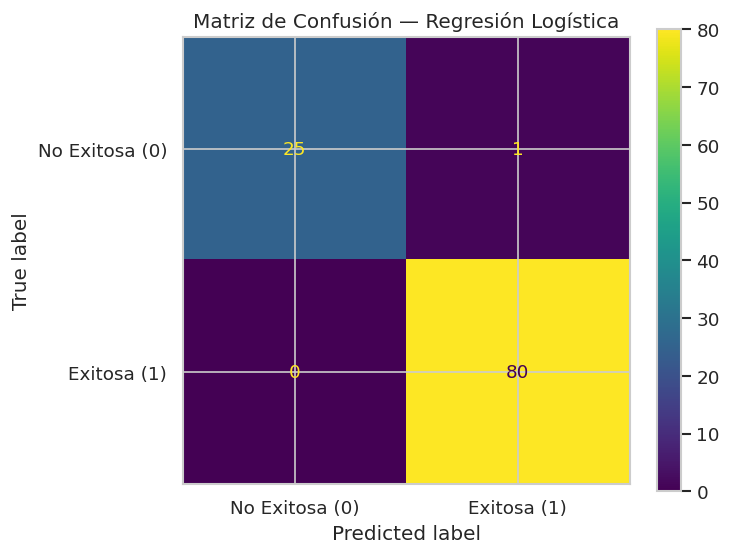

In [10]:
# ─────────────────────────────────────────────────────────────
# CELDA 9 — Matriz de Confusión
# ─────────────────────────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Exitosa (0)", "Exitosa (1)"]
)

disp.plot(ax=ax)

plt.title("Matriz de Confusión — Regresión Logística")

ruta = os.path.join(
    GRAFICAS_DIR,
    "matriz_confusion_logistica.png"
)

plt.savefig(ruta, bbox_inches="tight")

print(f"✅ Matriz guardada en:\n{ruta}")

plt.show()

✅ Curva ROC guardada en:
/home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/regresion_logistica_binaria/curva_roc_logistica.png


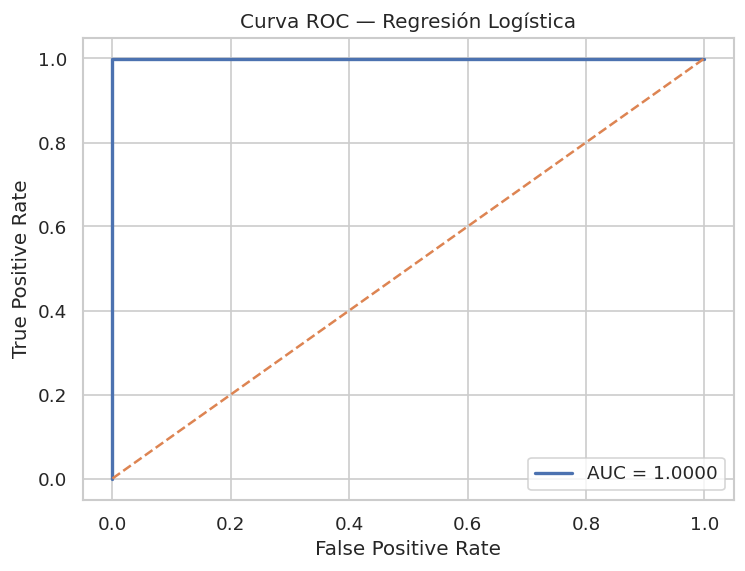

In [11]:
# ─────────────────────────────────────────────────────────────
# CELDA 10 — Curva ROC
# ─────────────────────────────────────────────────────────────

y_prob = modelo.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc:.4f}"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curva ROC — Regresión Logística")

plt.legend()

ruta = os.path.join(
    GRAFICAS_DIR,
    "curva_roc_logistica.png"
)

plt.savefig(ruta, bbox_inches="tight")

print(f"✅ Curva ROC guardada en:\n{ruta}")

plt.show()

✅ Coeficientes guardados en:
/home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/regresion_logistica_binaria/coeficientes_logistica.png


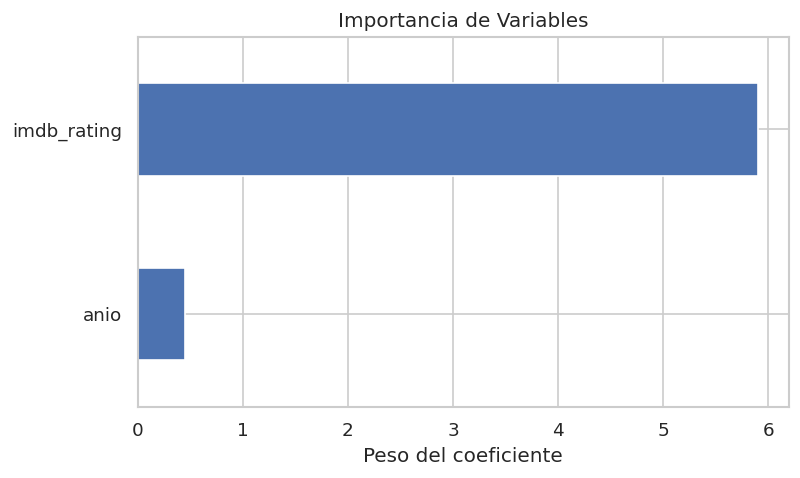

In [12]:
# ─────────────────────────────────────────────────────────────
# CELDA 11 — Importancia de variables
# ─────────────────────────────────────────────────────────────

coeficientes = pd.Series(
    modelo.coef_[0],
    index=["anio", "imdb_rating"]
)

coeficientes = coeficientes.sort_values()

plt.figure(figsize=(7,4))

coeficientes.plot(
    kind="barh"
)

plt.title("Importancia de Variables")

plt.xlabel("Peso del coeficiente")

ruta = os.path.join(
    GRAFICAS_DIR,
    "coeficientes_logistica.png"
)

plt.savefig(ruta, bbox_inches="tight")

print(f"✅ Coeficientes guardados en:\n{ruta}")

plt.show()